<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [46]:
df=pd.read_csv('/content/penguins.csv')
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [48]:
for col in df.select_dtypes(include=np.number).columns:
  df[col]=df[col].fillna(df[col].median())
for col in df.select_dtypes(include=object).columns:
  df[col]=df[col].fillna(df[col].mode()[0])

In [49]:
le_dict={}
for col in df.select_dtypes(include=object).columns:
  le=LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col]=le

In [50]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.10,18.7,181.0,3750.0,2
1,39.50,17.4,186.0,3800.0,1
2,40.30,18.0,195.0,3250.0,1
3,44.45,17.3,197.0,4050.0,2
4,36.70,19.3,193.0,3450.0,1


In [51]:
x=df.drop('sex',axis=1)
y=df['sex']


In [52]:
scaler=StandardScaler()
x=scaler.fit_transform(x)


In [53]:
pca=PCA()
param_grid={'n_components':list(range(1,x.shape[1]+1))}
grid_search=GridSearchCV(pca,param_grid,cv=10)
grid_search.fit(x)

best_n=grid_search.best_params_['n_components']
print("Best number of components:",best_n)

Best number of components: 1


In [54]:
pca=PCA(n_components=best_n)
x_pca=pca.fit_transform(x)
x_pca

array([[-1.27063054],
       [-0.85787006],
       [-1.37374369],
       [-0.10711869],
       [-1.91854976],
       [-1.81176492],
       [-1.16560252],
       [-0.73193499],
       [-1.86736378],
       [-0.45639863],
       [-1.3685633 ],
       [-1.0934239 ],
       [-1.23039748],
       [-1.91487355],
       [-1.85262456],
       [-1.34575578],
       [-1.63210845],
       [-0.80641034],
       [-2.03515495],
       [-0.88634994],
       [-1.59223232],
       [-1.54029319],
       [-1.69208328],
       [-1.04958491],
       [-0.88136844],
       [-1.67933132],
       [-1.25063302],
       [-1.36898341],
       [-1.86195087],
       [-1.01104457],
       [-1.13011724],
       [-1.19619797],
       [-1.36705088],
       [-1.0094026 ],
       [-1.46907941],
       [-1.54035186],
       [-1.46746988],
       [-1.05741493],
       [-1.94755517],
       [-0.56367056],
       [-1.85607046],
       [-0.89211697],
       [-2.0757265 ],
       [-0.466541  ],
       [-1.64688673],
       [-0

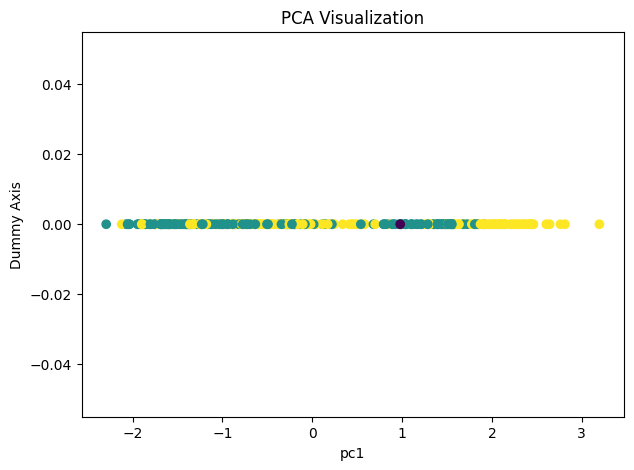

In [55]:
plt.figure(figsize=(7,5))
plt.scatter(x_pca[:,0],np.zeros(x_pca.shape[0]),c=y)
plt.xlabel("pc1")
plt.ylabel("Dummy Axis")
plt.title("PCA Visualization")
plt.show()

In [56]:
x_train,x_test,y_train,y_test=train_test_split(
    x_pca,y,test_size=0.2,random_state=42
)

In [57]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3,4,5,6],
    'min_samples_split': [2,3,5,10],
    'min_samples_leaf': [1,2,3,4]
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=10)
grid_dt.fit(x_train, y_train)

best_model = grid_dt.best_estimator_

print("Bestnparameters:",grid_dt.best_params_)
print("besy criterion:",grid_dt.best_params_['criterion'])

Bestnparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
besy criterion: entropy


In [58]:
y_pred=best_model.predict(x_test)


In [59]:
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred,average='weighted')
print("Accuracy:",acc)
print("F1 Score:",f1)

Accuracy: 0.6521739130434783
F1 Score: 0.6427932418270582


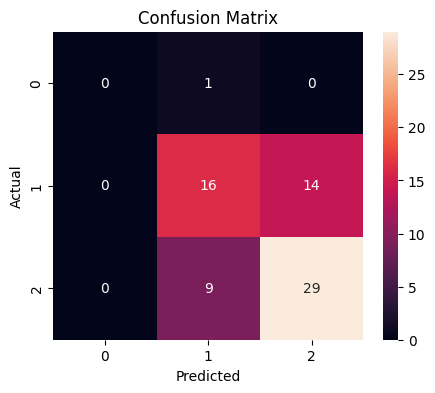

In [60]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()